## Task Description 
Build a machine learning model to predict whether an employee will leave the company or stay.

## Dataset
HR Employee Dataset (https://www.kaggle.com/datasets/giripujar/hr-analytics)

## Overall,
Task Steps
- Load the dataset using pandas
- Perform basic EDA
- Preprocess the data
- Evaluate the model using:
Accuracy
Precision
Recall
F1-score
Confusion Matrix
- Briefly explain the results and important features

## download data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("giripujar/hr-analytics")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moust\.cache\kagglehub\datasets\giripujar\hr-analytics\versions\1


## import libraries

In [5]:
import pandas as pd
import os 
from sklearn.preprocessing import OneHotEncoder
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
warnings.filterwarnings('ignore')

## read data

In [8]:
os.listdir(path)

['HR_comma_sep.csv']

In [9]:
data=pd.read_csv(path+'/HR_comma_sep.csv',sep=',')

In [10]:
data.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## data preprocessing

In [12]:
data.shape

(14999, 10)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [14]:
data.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [15]:
for i in data.columns:
    if data[i].dtype==object:
        print(data[i].value_counts())
        print('=====================')

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


In [16]:
department_encoded = pd.get_dummies(data['Department'], prefix='Department')

salary_map = {
    'low': 0,
    'medium': 1,
    'high': 2
}

data['salary'] = data['salary'].map(salary_map)

data = pd.concat([data, department_encoded], axis=1)

data.drop(columns=['Department'], inplace=True)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_montly_hours    14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   Work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5years   14999 non-null  int64  
 8   salary                  14999 non-null  int64  
 9   Department_IT           14999 non-null  bool   
 10  Department_RandD        14999 non-null  bool   
 11  Department_accounting   14999 non-null  bool   
 12  Department_hr           14999 non-null  bool   
 13  Department_management   14999 non-null  bool   
 14  Department_marketing    14999 non-null

In [47]:
data['left'].unique()

array([1, 0], dtype=int64)

## data splitting

In [21]:
x=data.drop('left',axis=1)
y=data.left

In [23]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [25]:
model=LogisticRegression()

In [27]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [29]:
model.score(xtrain,ytrain)

0.7935661305108759

In [31]:
model.score(xtest,ytest)

0.7873333333333333

In [33]:
accuracy_score(ytest,model.predict(xtest))

0.7873333333333333

In [35]:
precision_score(ytest,model.predict(xtest))

0.580568720379147

In [37]:
recall_score(ytest,model.predict(xtest))

0.34702549575070823

In [39]:
f1_score(ytest,model.predict(xtest))

0.43439716312056736

In [41]:
cm=confusion_matrix(ytest,model.predict(xtest))

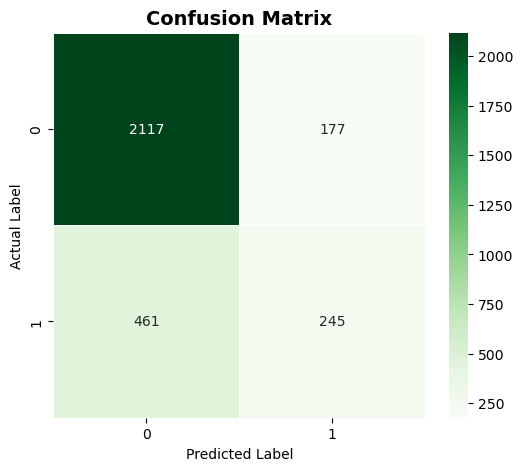

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Greens",
            linewidths=0.5,
            linecolor="white")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix", fontsize=14, weight="bold")

plt.show()

In [49]:
corr = data.corr(numeric_only=True)

corr_with_target = corr['left'].sort_values(
    key=abs,
    ascending=False
)

print(corr_with_target)

left                      1.000000
satisfaction_level       -0.388375
salary                   -0.157898
Work_accident            -0.154622
time_spend_company        0.144822
average_montly_hours      0.071287
promotion_last_5years    -0.061788
Department_RandD         -0.046596
Department_management    -0.046035
Department_hr             0.028249
number_project            0.023787
Department_technical      0.020076
Department_accounting     0.015201
Department_product_mng   -0.011029
Department_IT            -0.010925
Department_support        0.010700
Department_sales          0.009923
last_evaluation           0.006567
Department_marketing     -0.000859
Name: left, dtype: float64


In [51]:
cm = data.corr(numeric_only=True)

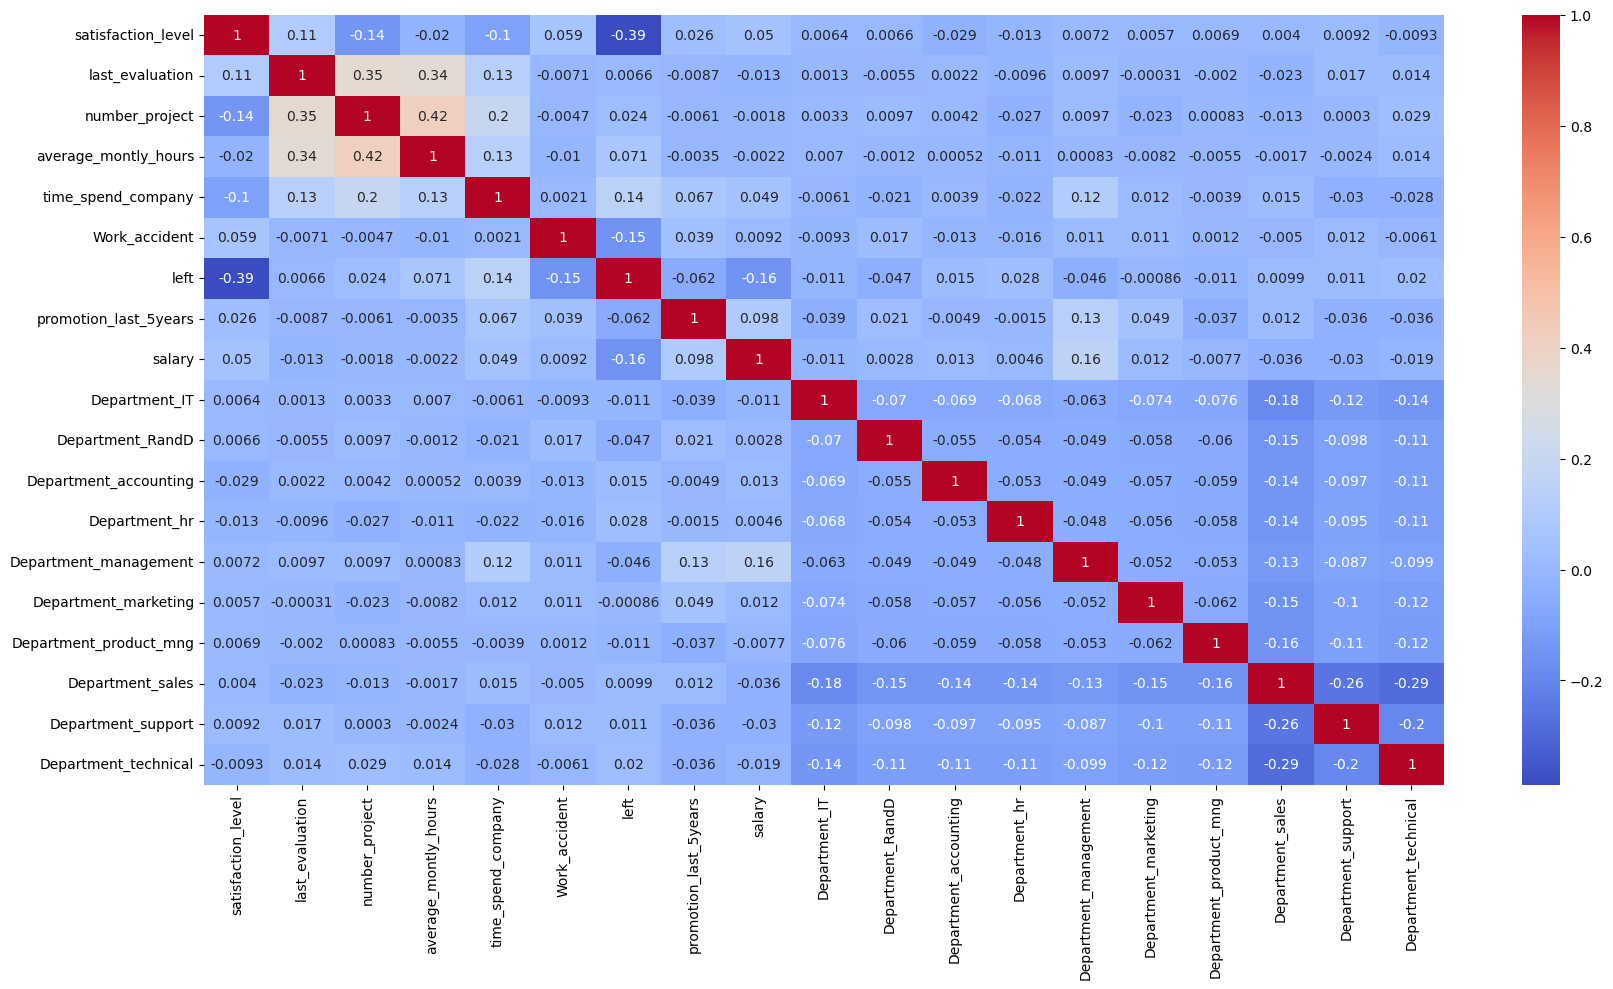

In [63]:
plt.figure(figsize=(20,10))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.show()